# Skin Lesion Classification using CNN (V2 — Improved)

## Semester Project – Programming for AI

### Team Members
- bscs24043 Ibrahim Butt
- bscs24095 Waize Arif
- bscs24139 Syed Jaffar Raza Kazmi
- bscs24083 Muhammad Moiz

### Objective
Build a Convolutional Neural Network (CNN) model to classify skin lesion images.

### Changes from V1
- Stratified train/test split (balanced class distribution)
- Learning rate scheduler (ReduceLROnPlateau)
- Early stopping with best model saving
- Test-Time Augmentation (TTA) for evaluation
- More epochs (80) with generous patience
- Per-class accuracy reporting and training curves

# Python Imports

In [1]:
!pip install torchmetrics
!pip install torchvision
!pip install scikit-learn

import torch
import torchvision
from torch.utils.data import DataLoader, Subset
import torchmetrics
from torchmetrics import ConfusionMatrix
import matplotlib.pyplot as plt
import numpy as np
from torch import nn
from timeit import default_timer as timer
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from sklearn.model_selection import train_test_split


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
!cp "/content/drive/MyDrive/skin_lesion/skin_datasetv2.zip" "/content/"

!unzip -q "/content/skin_datasetv2.zip" -d "/content/"

!ls "/content/dataset"

replace /content/dataset/healthy/healthy_42.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
acne  bruises  burn  healthy  pigmentation


# Check Version and Device

In [17]:
print(f"PyTorchColab Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

PyTorchColab Version: 2.10.0+cu128
Torchvision Version: 0.25.0+cu128
Using device: cuda


# HyperParameters

In [18]:
# --- HYPERPARAMETER DASHBOARD ---

SEED = 42                # seed for reproducibility
TRAIN_SPLIT = 0.8        # train test split value, 80% train, 20% test
BATCH_SIZE = 32          # same as V1
LEARNING_RATE = 0.0005   # same as V1
EPOCHS = 80              # more room, early stopping handles the rest
DROPOUT_RATE = 0.3       # same as V1
IMAGE_SIZE = 224         # same as V1
PATIENCE = 15            # generous patience for small dataset

# Transforming Data

In [19]:
# DATA TRANSFORMING

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomVerticalFlip(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])
print("Transforms defined successfully.")

Transforms defined successfully.


# Data Loading

**V2 Change:** Stratified split ensures every class has proportional representation in both train and test sets. With random split and small data, some classes can end up underrepresented.

In [20]:
dataset_path = "/content/dataset"

train_data_full = ImageFolder(root=dataset_path, transform=train_transforms)
test_data_full  = ImageFolder(root=dataset_path, transform=test_transforms)


all_targets = train_data_full.targets
all_indices = list(range(len(train_data_full)))

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=(1 - TRAIN_SPLIT),
    stratify=all_targets,
    random_state=SEED
)

train_dataset = Subset(train_data_full, train_indices)
test_dataset  = Subset(test_data_full, test_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Classes: {train_data_full.classes}")
print(f"Total images: {len(train_data_full)}")
print(f"Training: {len(train_dataset)} | Testing: {len(test_dataset)}")

from collections import Counter
train_class_counts = Counter([all_targets[i] for i in train_indices])
test_class_counts = Counter([all_targets[i] for i in test_indices])
print(f"\nTrain distribution: {dict(sorted(train_class_counts.items()))}")
print(f"Test distribution:  {dict(sorted(test_class_counts.items()))}")
print("Data loaded correctly. Train and Test are stratified and separated.")

Classes: ['acne', 'bruises', 'burn', 'healthy', 'pigmentation']
Total images: 1289
Training: 1031 | Testing: 258

Train distribution: {0: 234, 1: 240, 2: 118, 3: 182, 4: 257}
Test distribution:  {0: 58, 1: 60, 2: 29, 3: 46, 4: 65}
Data loaded correctly. Train and Test are stratified and separated.


# The CNN Class

Same architecture as V1 — it already achieved 77%.

In [21]:
class SkinCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(DROPOUT_RATE)

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, 5)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))

        x = self.flatten(x)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SkinCNN().to(device)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=4, factor=0.5
)

print("CNN built and pushed to GPU.")


CNN built and pushed to GPU.


# Training Loop

In [22]:
train_loss_history = []
test_acc_history = []
best_accuracy = 0.0
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_loss_history.append(epoch_loss)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Test-Time Augmentation: average predictions from
            # original + horizontally flipped + vertically flipped
            out_original = model(inputs)
            out_hflip    = model(torch.flip(inputs, dims=[3]))
            out_vflip    = model(torch.flip(inputs, dims=[2]))

            outputs = (out_original + out_hflip + out_vflip) / 3.0

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_acc = 100 * correct / total
    test_acc_history.append(epoch_acc)

    scheduler.step(epoch_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss:.4f} | Test Acc: {epoch_acc:.2f}% | LR: {current_lr:.6f}")

    # Save best model
    if epoch_acc > best_accuracy:
        best_accuracy = epoch_acc

        best_model_state = model.state_dict().copy()

        torch.save(model.state_dict(), 'best_skin_model.pth')

        patience_counter = 0
        print(f"  -> New best accuracy! Saving model to best_skin_model.pth")
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs (no improvement for {PATIENCE} epochs).")
        break

# Restore best model
model.load_state_dict(best_model_state)
print(f"\nTraining complete. Best Test Accuracy: {best_accuracy:.2f}%")

Epoch 1/80 | Loss: 6.7132 | Test Acc: 42.64% | LR: 0.000500
  -> New best accuracy! Saving model.
Epoch 2/80 | Loss: 1.4517 | Test Acc: 50.00% | LR: 0.000500
  -> New best accuracy! Saving model.
Epoch 3/80 | Loss: 1.2799 | Test Acc: 53.49% | LR: 0.000500
  -> New best accuracy! Saving model.
Epoch 4/80 | Loss: 1.2037 | Test Acc: 63.57% | LR: 0.000500
  -> New best accuracy! Saving model.
Epoch 5/80 | Loss: 1.1587 | Test Acc: 63.95% | LR: 0.000500
  -> New best accuracy! Saving model.
Epoch 6/80 | Loss: 1.1113 | Test Acc: 64.34% | LR: 0.000500
  -> New best accuracy! Saving model.
Epoch 7/80 | Loss: 1.0065 | Test Acc: 63.95% | LR: 0.000500
Epoch 8/80 | Loss: 1.0288 | Test Acc: 62.79% | LR: 0.000500
Epoch 9/80 | Loss: 0.9032 | Test Acc: 67.44% | LR: 0.000500
  -> New best accuracy! Saving model.
Epoch 10/80 | Loss: 0.8195 | Test Acc: 68.99% | LR: 0.000500
  -> New best accuracy! Saving model.
Epoch 11/80 | Loss: 0.7832 | Test Acc: 70.16% | LR: 0.000500
  -> New best accuracy! Saving mod

# Training Curves

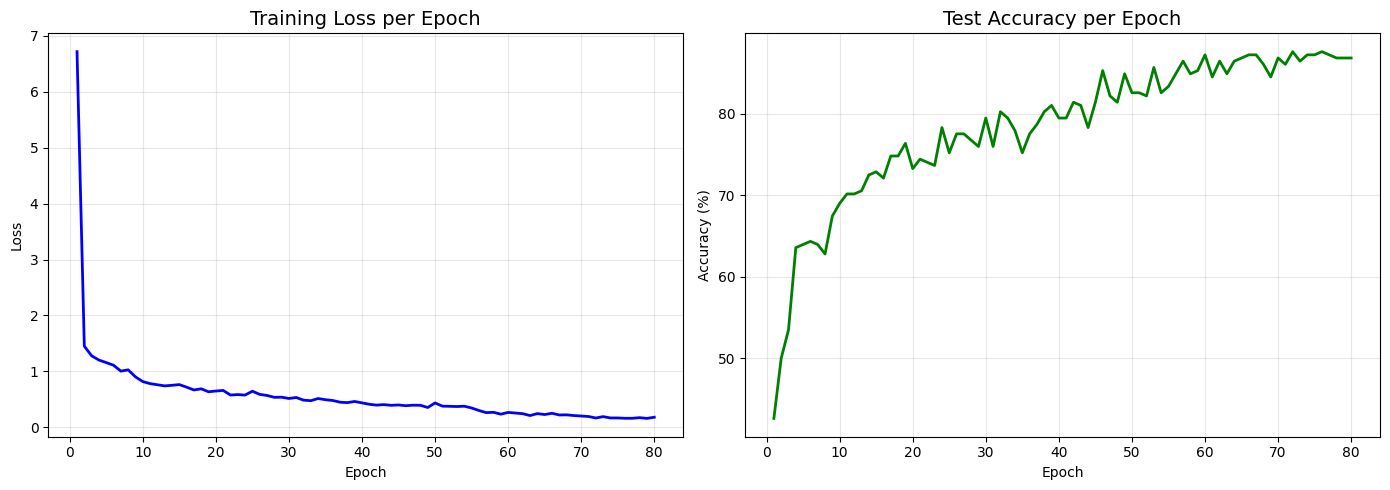

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(range(1, len(train_loss_history)+1), train_loss_history, 'b-', linewidth=2)
ax1.set_title('Training Loss per Epoch', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(range(1, len(test_acc_history)+1), test_acc_history, 'g-', linewidth=2)
ax2.set_title('Test Accuracy per Epoch', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Accuracy and Prediction Checking

Per-Class Classification Report:
              precision    recall  f1-score   support

        acne       0.92      1.00      0.96        58
     bruises       0.87      0.87      0.87        60
        burn       0.68      0.59      0.63        29
     healthy       0.84      0.89      0.86        46
pigmentation       0.92      0.86      0.89        65

    accuracy                           0.87       258
   macro avg       0.84      0.84      0.84       258
weighted avg       0.87      0.87      0.87       258



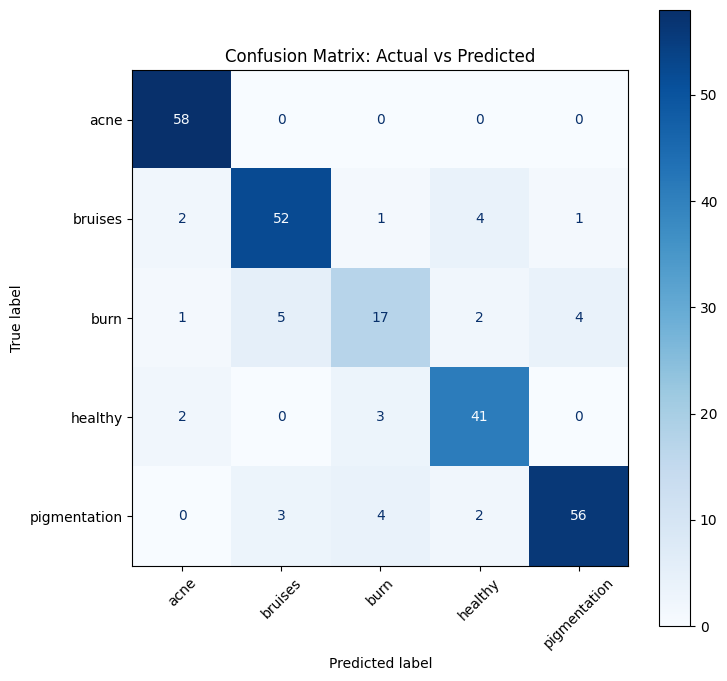

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)

        # TTA for final evaluation too
        out_original = model(inputs)
        out_hflip    = model(torch.flip(inputs, dims=[3]))
        out_vflip    = model(torch.flip(inputs, dims=[2]))
        outputs = (out_original + out_hflip + out_vflip) / 3.0

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Per-class accuracy report
print("Per-Class Classification Report:")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=train_data_full.classes))

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_data_full.classes)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix: Actual vs Predicted")
plt.show()

# Testing true vs predicted

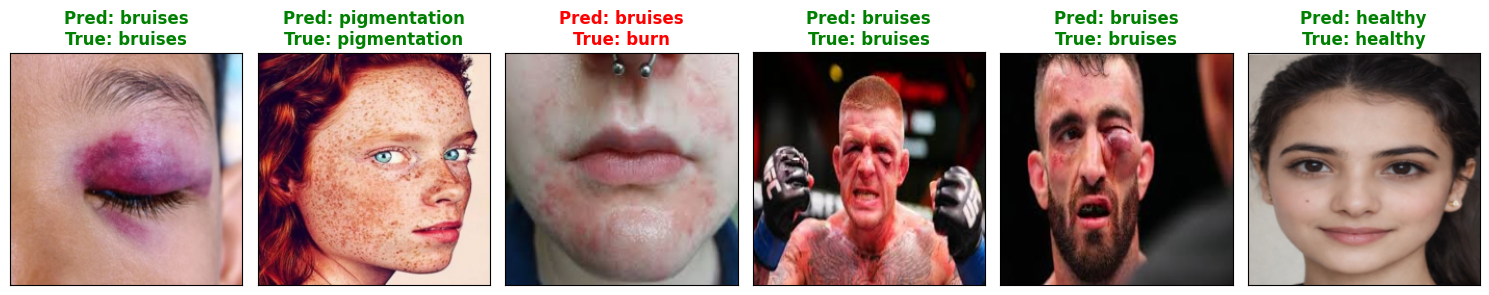

In [25]:
# batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.to(device)

# Make predictions
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()

# Plot images
fig = plt.figure(figsize=(15, 6))
for idx in range(6):
    ax = fig.add_subplot(1, 6, idx+1, xticks=[], yticks=[])

    img = images[idx] / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

    true_label = train_data_full.classes[labels[idx]]
    pred_label = train_data_full.classes[preds[idx]]

    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontweight='bold')

plt.tight_layout()
plt.show()

# gradio demo v2

In [ ]:
import gradio as gr
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms

# 1. Updated classes based on your recent report
class_names = ['acne', 'bruises', 'burn', 'healthy', 'pigmentation']

demo_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# 2. Load the best V2 model
model.load_state_dict(torch.load('best_skin_model.pth', map_location=device))
model.eval()

# 3. V2 Prediction Function
def predict_skin_lesion(img):
    if img is None:
        return None

    img = img.convert('RGB')
    input_tensor = demo_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out_original = model(input_tensor)
        out_hflip = model(torch.flip(input_tensor, dims=[3]))
        out_vflip = model(torch.flip(input_tensor, dims=[2]))

        outputs = (out_original + out_hflip + out_vflip) / 3.0
        probabilities = F.softmax(outputs[0], dim=0)

    result_dict = {class_names[i]: float(probabilities[i]) for i in range(len(class_names))}
    return result_dict

# 4. Launch Web App
demo = gr.Interface(
    fn=predict_skin_lesion,
    inputs=gr.Image(type="pil", label="Upload Skin Image"),
    outputs=gr.Label(num_top_classes=5, label="Model Predictions"),
    title="⚕️ Skin Lesion Classifier AI (V2)",
    description="Upload face image. Our 4-layer CNN will analyze the textures and predict the condition.",
    allow_flagging="never",
    theme=gr.themes.Soft()
)

demo.launch(share=True, debug=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://921f5c693f5b656acc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
